# Build models

* Goal - Model A:
    * Input: images.
    * Output: Action.

* Goal - Model B:
    * Input: images and language instruction.
    * Output: Action.

* Notes:
    * Data is uploaded from hdf5 file -> No need to use Tensorflow.
* Environment: robotic (env_robotic.yml)


In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import os
...

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset, WeightedRandomSampler
from torchvision import transforms
import torchvision.transforms.functional as TF
from torch.optim import Adam, SGD
from sentence_transformers import SentenceTransformer

import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path
import h5py
import numpy as np
import math

from simulation.miniarm_env import MiniArmEnv
from simulation.oracle import Oracle, collect_demos
import pybullet as p


# torch.set_num_threads(6)
print(f"threads set to: {torch.get_num_threads()}")

threads set to: 12


pybullet build time: Nov 28 2023 23:45:17


# Data preparation

##### Load dataset
##### Discretize action space
##### Resize images
##### Embedding language instruction
##### Create dataloaders.

In [2]:
#### load data slice as hdf5
path_data = str(Path.cwd().parent / "data")

data = []
metadata = {}
with h5py.File(f"{path_data}/combined_datasets.h5", "r") as f:
    for data_name in f.keys(): # access a single dataset.
        total_samples = 0
        data_grp = f[data_name]
        metadata[data_name] = {"actions_metadata": json.loads(data_grp.attrs["actions_metadata"])}
        print(f"n_episodes: {len(data_grp.keys())}")
        for episode_idx, episode_key in enumerate(data_grp.keys()): # access a single episode.
            grp = data_grp[episode_key]
            grp_images = grp["images"]
            grp_action = grp["actions"]
            grp_language = grp["language"]
            
            # load data once per episode
            image_arrays  = {key: grp_images[key][:] for key in grp_images.keys()}
            action_arrays = {key: grp_action[key][:] for key in grp_action.keys()}
            language_arrays = {key: grp_language[key][:] for key in grp_language.keys()}

            # n_steps from any action array (they should all share dim 0)
            n_steps = next(iter(action_arrays.values())).shape[0]
            total_samples += n_steps

            # flatten episode into per-timestep dicts
            for t in range(n_steps):
                sample = {key: arr[t][:-1] if arr.ndim == 2 else arr[t] for key, arr in action_arrays.items()}
                sample.update({key: arr[t] for key, arr in image_arrays.items()})
                sample.update({key: arr[t] for key, arr in language_arrays.items()})
                sample["episode_idx"] = episode_idx
                sample["dataset_name"] = data_name  # useful if you later mix datasets

                data.append(sample)
                
        metadata[data_name]["image_keys"] = list(grp_images.keys())
        metadata[data_name]["action_keys"] = list(grp_action.keys())
        metadata[data_name]["language_keys"] = list(grp_language.keys())
        metadata[data_name]["total_samples"] = total_samples

'''
Each sample represents a time step.
Number of samples: sum(n_steps_episode)_episode, sum over all steps across all episodes both datasets together.
'''

n_episodes: 16
n_episodes: 16


'\nEach sample represents a time step.\nNumber of samples: sum(n_steps_episode)_episode, sum over all steps across all episodes both datasets together.\n'

In [3]:
print(metadata.keys())
print(metadata["stanford_hydra_dataset_converted_externally_to_rlds"]["total_samples"])
print(data[9760].keys())
print(data[9761].keys())
# np.stack([sample["dataset_name"] for sample in data])[9761:]

dict_keys(['stanford_hydra_dataset_converted_externally_to_rlds', 'taco_play'])
9761
dict_keys(['actions', 'image', 'language_instruction', 'episode_idx', 'dataset_name'])
dict_keys(['actions', 'rel_actions_gripper', 'rel_actions_world', 'terminate_episode', 'rgb_gripper', 'rgb_static', 'natural_language_instruction', 'episode_idx', 'dataset_name'])


In [4]:
# print(data[10000]['actions'])
display(metadata["stanford_hydra_dataset_converted_externally_to_rlds"])
display(metadata["taco_play"])

{'actions_metadata': {'type': 'Tensor',
  'shape': [7],
  'dtype': "<dtype: 'float32'>",
  'description': "Documentation(desc='Robot action, consists of [3x EEF positional delta, 3x EEF orientation delta in euler angle, 1x close gripper].', value_range='')"},
 'image_keys': ['image'],
 'action_keys': ['actions'],
 'language_keys': ['language_instruction'],
 'total_samples': 9761}

{'actions_metadata': {'actions': {'type': 'Tensor',
   'shape': [7],
   'dtype': "<dtype: 'float32'>",
   'description': "Documentation(desc='absolute desired values for gripper pose (first 6 dimensions are x, y, z, yaw, pitch, roll), last dimension is open_gripper (-1 is open gripper, 1 is close)', value_range='')"},
  'terminate_episode': {'type': 'Tensor',
   'shape': [],
   'dtype': "<dtype: 'float32'>",
   'description': "Documentation(desc='', value_range='')"},
  'rel_actions_world': {'type': 'Tensor',
   'shape': [7],
   'dtype': "<dtype: 'float32'>",
   'description': "Documentation(desc='relative actions for gripper pose in the robot base frame (first 6 dimensions are x, y, z, yaw, pitch, roll), last dimension is open_gripper (-1 is open gripper, 1 is close)', value_range='')"},
  'rel_actions_gripper': {'type': 'Tensor',
   'shape': [7],
   'dtype': "<dtype: 'float32'>",
   'description': "Documentation(desc='relative actions for gripper pose in the gripper camera frame (fir

#### Discretize action space in 256 bins

Compute 1st/99th percentiles

In [5]:
N_BINS = 32 # before 256

action_percentiles = {} # keep track of action percentiles per dataset per action dimension.
data_discretized = []

def discretize(values: np.ndarray, p1: np.ndarray, p99: np.ndarray, n_bins: int = N_BINS) -> np.ndarray:
    """
    Maps continuous values (n_samples, action_dim) to discrete bins [0, n_bins-1],
    independently per dimension, using p1/p99 as the [lower, upper] range.
    Values outside [p1, p99] are clipped to the nearest bin.
    """
    action_dim = values.shape[-1] if values.ndim > 1 else 1 # values.shape = (n_steps*n_episodes, action_dimensions).
    values = values.reshape(-1, action_dim) # reshape in case shape is (n_samples,).

    discretized = np.zeros_like(values, dtype=np.int64)

    for d in range(action_dim):
        bin_edges = np.linspace(p1[d], p99[d], n_bins + 1)
        binned = np.digitize(values[:, d], bin_edges[1:-1], right=True)
        discretized[:, d] = np.clip(binned, 0, n_bins - 1)

    return discretized.squeeze()

def undiscretize(bin_indices, p1, p99, n_bins: int = 32) -> torch.Tensor:
    """
    Inverse of discretize(): maps bin indices [0, n_bins-1] back to continuous
    values, using the midpoint of each bin's range as the reconstruction.

    Accepts bin_indices/p1/p99 as either numpy arrays or torch tensors --
    normalizes everything to torch internally, so mixed numpy/torch inputs
    (a common source of confusing errors) can never reach the arithmetic below.

    bin_indices: (B, action_dim) int
    p1, p99:     (action_dim,) float -- same percentiles used during discretization
    Returns:     (B, action_dim) float torch.Tensor -- reconstructed continuous actions
    """
    if isinstance(bin_indices, np.ndarray):
        bin_indices = torch.from_numpy(bin_indices)
    if isinstance(p1, np.ndarray):
        p1 = torch.from_numpy(p1)
    if isinstance(p99, np.ndarray):
        p99 = torch.from_numpy(p99)

    bin_indices = bin_indices.float()
    p1 = p1.float()
    p99 = p99.float()

    bin_width = (p99 - p1) / n_bins
    continuous = p1 + (bin_indices + 0.5) * bin_width
    return continuous


for data_name in list(metadata.keys()):#metadata.keys():
    action_keys = metadata[data_name]["action_keys"]

    # filter samples belonging to this dataset only
    batch = [sample for sample in data if sample["dataset_name"] == data_name]
    
    action_percentiles[data_name] = {}

    # start each new sample as a shallow copy of the original (keeps images, episode_idx, dataset_name, etc.)
    batch_discretized = [dict(sample) for sample in batch]

    for action_key in action_keys:
        stacked = np.stack([sample[action_key] for sample in batch])
        if stacked.ndim == 1:
            stacked = stacked.reshape(-1, 1)

        p1 = np.percentile(stacked, 1, axis=0)
        p99 = np.percentile(stacked, 99, axis=0)
        action_percentiles[data_name][action_key] = {"p1": p1, "p99": p99}

        discretized = discretize(stacked, p1, p99, N_BINS)

        # overwrite the continuous action_key with its discretized version
        for sample_disc, disc_val in zip(batch_discretized, discretized.reshape(len(batch), -1)):
            sample_disc[action_key] = disc_val.squeeze()

        print(f"{data_name}\n{action_key}: shape={stacked.shape}\n"
              f"p1={p1}\np99={p99}\ndiscretized_range=[{discretized.min()}, {discretized.max()}]\n\n")

    data_discretized.extend(batch_discretized)

stanford_hydra_dataset_converted_externally_to_rlds
actions: shape=(9761, 6)
p1=[-0.01895591 -0.02405627 -0.02057381 -0.12112904 -0.16186282 -0.16376511]
p99=[0.02197458 0.02150433 0.02401781 0.12091041 0.11146203 0.16157938]
discretized_range=[0, 31]


taco_play
actions: shape=(1056, 6)
p1=[ 0.14739171 -0.41538738  0.19777607 -3.13861867 -0.53569646 -1.53636925]
p99=[0.49058009 0.62614233 0.55302485 3.13905847 0.12491795 1.73633049]
discretized_range=[0, 31]


taco_play
rel_actions_gripper: shape=(1056, 6)
p1=[-0.5188651  -1.04988477 -0.87823469 -0.84330282 -0.76780331 -1.98089754]
p99=[0.56948566 0.95734829 0.52781998 0.88023777 0.63672144 1.759892  ]
discretized_range=[0, 31]


taco_play
rel_actions_world: shape=(1056, 6)
p1=[-0.65884569 -1.04458029 -0.49734294 -0.74591375 -0.70896812 -1.77969494]
p99=[0.47416454 1.00982402 0.86957543 0.72206968 0.77220851 1.95908995]
discretized_range=[0, 31]


taco_play
terminate_episode: shape=(1056, 1)
p1=[0.]
p99=[1.]
discretized_range=[0, 31]


In [6]:
# test discretized and undiscretized produce inverse results
idx_element = 10000
bin_indices = torch.from_numpy(data_discretized[idx_element]['actions'].reshape(1, -1))

print(undiscretize(
    bin_indices=bin_indices,
    p1=action_percentiles[data_discretized[idx_element]['dataset_name']]['actions']['p1'],
    p99=action_percentiles[data_discretized[idx_element]['dataset_name']]['actions']['p99'],
    n_bins=32,
)
)
print(data[idx_element]['actions'])


tensor([[ 0.2814,  0.4797,  0.5364,  3.0410, -0.0712,  1.0716]])
[ 0.2848146   0.46722233  0.5354779   3.1059792  -0.07630603  1.0550355 ]


### TODO: Overwrite data -> do not save data_discretized.

In [7]:
# sanity checks, mirroring the original data structure
print(len(data_discretized))
print(data_discretized[9760].keys())
print(data_discretized[9761].keys())
# print(data[9760]["actions"], "->", data_discretized[9760]["actions"])
data_discretized[9761]['actions']

10817
dict_keys(['actions', 'image', 'language_instruction', 'episode_idx', 'dataset_name'])
dict_keys(['actions', 'rel_actions_gripper', 'rel_actions_world', 'terminate_episode', 'rgb_gripper', 'rgb_static', 'natural_language_instruction', 'episode_idx', 'dataset_name'])


array([18, 11,  1,  0, 20, 16])

#### Filter and rename variables. All datasets must have same keys.

In [8]:
def filter_keys(
    data: list[dict],
    keys_to_keep: dict[str, list[str]],
    renaming_keys: dict[str, list[tuple[str, str]]] = None,
) -> list[dict]:
    """
    Filters each sample in `data` down to a subset of keys, chosen per-dataset,
    and optionally renames some of those keys per-dataset.

    Args:
        data: list of sample dicts, each with a "dataset_name" field.
        keys_to_keep: maps dataset_name -> list of keys to preserve for
            samples belonging to that dataset (using the ORIGINAL key names).
        renaming_keys: maps dataset_name -> list of (old_name, new_name) tuples.
            Applied AFTER filtering, so old_name must be one of the kept keys.
            e.g.:
            {
                "taco_play": [("rgb_static", "image")],
            }

    Returns:
        A new list of filtered (and possibly renamed) dicts. Original `data`
        is left untouched.
    """
    renaming_keys = renaming_keys or {}
    filtered = []

    for sample in data:
        dataset_name = sample["dataset_name"]
        keys = keys_to_keep[dataset_name]  # which keys to keep for this sample's dataset

        filtered_sample = {key: sample[key] for key in keys}

        # apply renaming, if any is defined for this dataset
        for old_name, new_name in renaming_keys.get(dataset_name, []):
            filtered_sample[new_name] = filtered_sample.pop(old_name)

        filtered.append(filtered_sample)

    return filtered

keys_to_keep = {
    "stanford_hydra_dataset_converted_externally_to_rlds": ["actions", "image", "language_instruction","episode_idx", "dataset_name"],
    "taco_play": ["rel_actions_world", "rgb_static", "natural_language_instruction", "episode_idx", "dataset_name"],
}

renaming_keys = {
    "taco_play": [("rgb_static", "image"), ("rel_actions_world", "actions"), ("natural_language_instruction","language_instruction")],  # so both datasets share the key "image"
}

data_filtered = filter_keys(data_discretized, keys_to_keep, renaming_keys)

print(data_filtered[9760].keys())  # dict_keys(['actions', 'image', 'episode_idx', 'dataset_name'])
print(data_filtered[9761].keys())  # dict_keys(['actions', 'image', 'episode_idx', 'dataset_name'])

dict_keys(['actions', 'image', 'language_instruction', 'episode_idx', 'dataset_name'])
dict_keys(['episode_idx', 'dataset_name', 'image', 'actions', 'language_instruction'])


#### Resize images


In [9]:
def episode_to_ids(dataset: list[dict]):
  # key: (dataset_name, episode_idx); value: list of sample indices belonging to that episode
  episode_to_indices: dict[tuple[str, int], list[int]] = {}
  for i, sample in enumerate(dataset):
      key = (sample["dataset_name"], sample["episode_idx"])
      episode_to_indices.setdefault(key, []).append(i)
  return episode_to_indices

def image_resizing(data: list[dict], out_image_dim: int = 224, mean: torch.Tensor = None, std: torch.Tensor = None):
    """
    Resize + normalize images in `data`.

    If mean/std are not provided, they are computed separately for each
    (dataset_name, episode_idx, image_key) group — since lighting/scene
    statistics can vary a lot across episodes and datasets, normalizing
    globally would blur that out.

    If mean/std ARE provided, that FIXED pair is used for every image instead
    of computing per-episode stats -- useful for deployment/inference time,
    where you don't have a whole episode available in advance to compute
    statistics from (e.g. a live closed-loop rollout, one frame at a time).

    Modifies `data` in place: image arrays are replaced with normalized,
    resized torch.Tensor images of shape (3, out_image_dim, out_image_dim).
    """
    # group sample indices by (dataset_name, episode_idx)
    episode_to_indices: dict[tuple[str, int], list[int]] = {}
    for i, sample in enumerate(data):
        key = (sample["dataset_name"], sample["episode_idx"])
        episode_to_indices.setdefault(key, []).append(i)

    for (dataset_name, episode_idx), indices in episode_to_indices.items():
        # gather every image for this image_key within this one episode
        raw_images = [data[i]['image'] for i in indices]  # each (H, W, 3) uint8

        # convert to tensor stack (N, 3, H, W), scaled to [0, 1]
        episode_stack = torch.stack([TF.to_tensor(img) for img in raw_images])

        # use provided mean/std if given, otherwise compute per-episode stats
        if mean is None:
            episode_mean = episode_stack.mean(dim=[0, 2, 3])
        else:
            episode_mean = mean

        if std is None:
            episode_std = episode_stack.std(dim=[0, 2, 3]).clamp(min=1e-6)  # avoid div-by-zero
        else:
            episode_std = std

        
        transform = transforms.Compose([
            transforms.Resize((out_image_dim, out_image_dim),
                                interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.Normalize(mean=episode_mean, std=episode_std),
        ])

        # apply resize+normalize to each image, write back into data in place
        for i, img_tensor in zip(indices, episode_stack):
            data[i]['image'] = transform(img_tensor)

    return data


data_filtered = image_resizing(data_filtered)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Dataset: stanford_hydra_dataset_converted_externally_to_rlds
Episode: 0
Image shape: torch.Size([3, 224, 224])




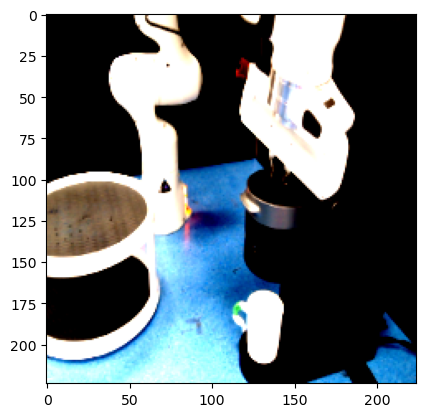

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Dataset: stanford_hydra_dataset_converted_externally_to_rlds
Episode: 0
Image shape: torch.Size([3, 224, 224])




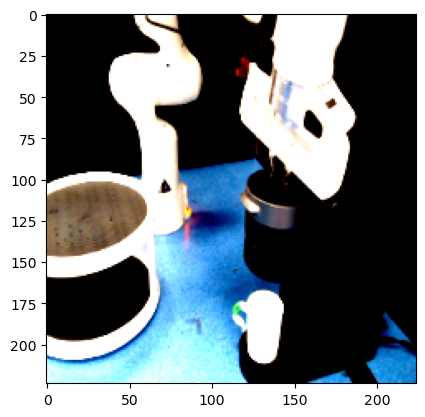

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Dataset: stanford_hydra_dataset_converted_externally_to_rlds
Episode: 0
Image shape: torch.Size([3, 224, 224])




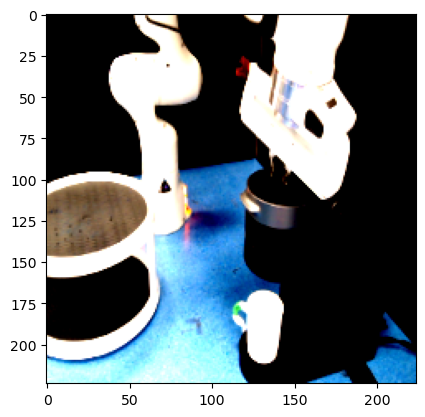

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Dataset: stanford_hydra_dataset_converted_externally_to_rlds
Episode: 0
Image shape: torch.Size([3, 224, 224])




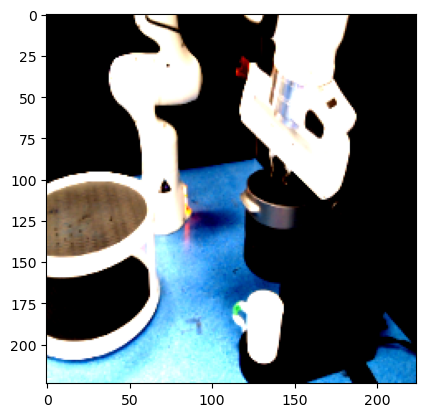

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Dataset: stanford_hydra_dataset_converted_externally_to_rlds
Episode: 0
Image shape: torch.Size([3, 224, 224])




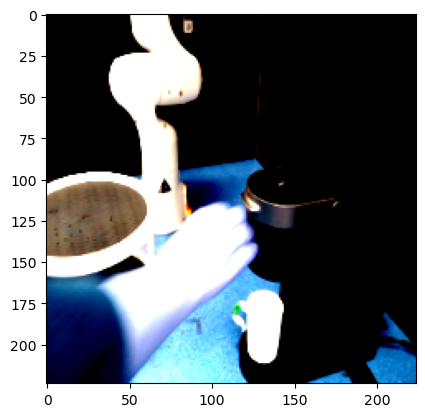

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Dataset: stanford_hydra_dataset_converted_externally_to_rlds
Episode: 0
Image shape: torch.Size([3, 224, 224])




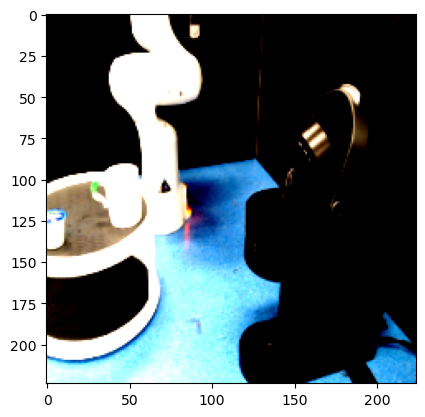

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Dataset: stanford_hydra_dataset_converted_externally_to_rlds
Episode: 0
Image shape: torch.Size([3, 224, 224])




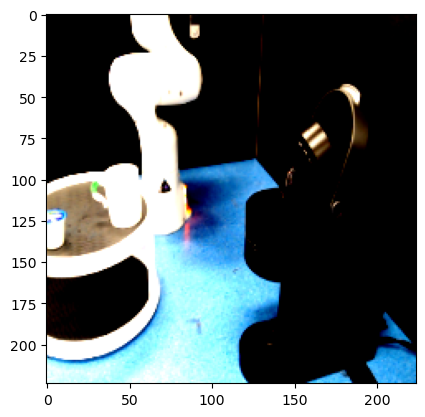

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Dataset: stanford_hydra_dataset_converted_externally_to_rlds
Episode: 0
Image shape: torch.Size([3, 224, 224])




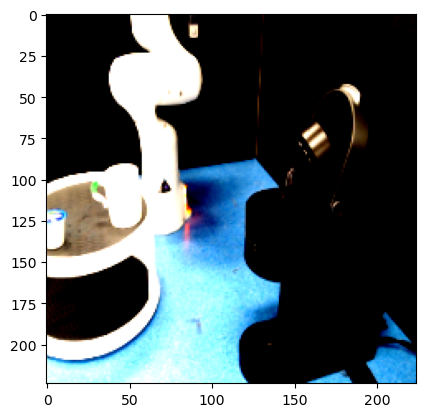

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Dataset: stanford_hydra_dataset_converted_externally_to_rlds
Episode: 0
Image shape: torch.Size([3, 224, 224])




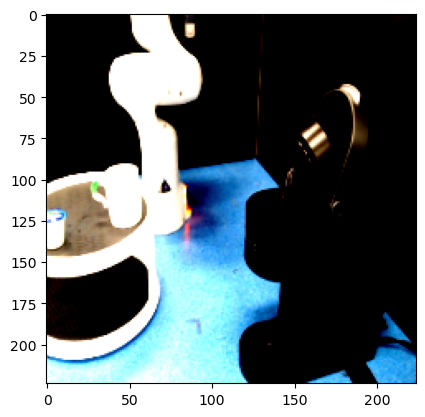

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Dataset: stanford_hydra_dataset_converted_externally_to_rlds
Episode: 0
Image shape: torch.Size([3, 224, 224])




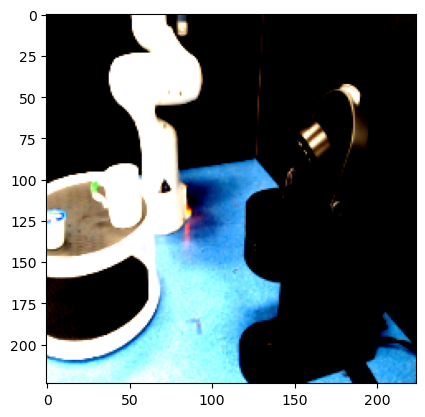

In [10]:
def plot_images(data: list[dict], metadata: dict, data_name: str):
    # Dict: keys=(data_name, episode_idx), value=[indices in dataset of pair (data_name, episode_idx)].
    episode_to_indices = episode_to_ids(data)
    start = 0
    if data_name == "taco_play":
        start = metadata["stanford_hydra_dataset_converted_externally_to_rlds"]["total_samples"] + 1
    
    for idx in range(start, start+10):
        img = data[idx]["image"]
        print(f"Dataset: {data_name}\nEpisode: {data[idx]['episode_idx']}\nImage shape: {img.shape}\n\n")
        if img.shape[0] == 3:
            img = img.permute(1,2,0)
            
        plt.imshow(img)
        plt.show()

# data_filtered[0]
# metadata['taco_play']["total_samples"]
plot_images(data_filtered, metadata, "stanford_hydra_dataset_converted_externally_to_rlds")

#### Embedding language instruction 


In [11]:
def _to_str(x) -> str:
    if isinstance(x, np.ndarray):
        x = x.item()
    return x.decode("utf-8") if isinstance(x, bytes) else str(x)

def add_language_embeddings(data, instruction_keys: dict[str, str],
                            model_name="all-MiniLM-L6-v2", out_key="language_embedding"):
    """
    instruction_keys: dataset_name -> which entry of metadata[...]["language_keys"]
    holds the natural-language instruction, e.g.
      {"taco_play": "natural_language_instruction", "stanford_hydra...": "..."}
    Encodes each UNIQUE instruction once (frozen encoder) and stores a (D_text,)
    float tensor under sample[out_key].
    """
    texts = [_to_str(s[instruction_keys[s["dataset_name"]]]) for s in data]
    uniq = sorted(set(texts))
    print(f"{len(uniq)} unique instructions")

    text_model = SentenceTransformer(model_name)
    emb = text_model.encode(uniq, convert_to_tensor=True, normalize_embeddings=True).cpu()
    lookup = {t: e for t, e in zip(uniq, emb)}

    for s, t in zip(data, texts):
        s[out_key] = lookup[t].clone()
    return data, emb.shape[1], text_model   # keep text_model for rollout-time encoding

data_filtered, lang_dim, text_model = add_language_embeddings(
    data_filtered,
    instruction_keys={
        "stanford_hydra_dataset_converted_externally_to_rlds": "language_instruction",
        "taco_play": "language_instruction",
    },
)

19 unique instructions


#### Dataloaders 
* split_by_episode(): Episodes appearing in training set must not appear in validation set.

In [12]:
def split_by_episode(dataset: list[dict], val_frac: float = 0.1, seed: int = 42):
    '''
    - For each sample, get its (dataset_name, episode_idx) pair, since episode_idx
      alone is not globally unique (it resets to 0 for each dataset_name).
    - Split episodes into train/val sets, constrained to not overlap.
    - Use sample indices to build train/val Subsets, enforcing different episodes
      (within each dataset_name) across the two splits.
    '''

    episode_to_indices = episode_to_ids(dataset)
    episode_ids = sorted(episode_to_indices.keys())  # sorted list of (dataset_name, episode_idx) tuples

    rng = np.random.default_rng(seed)
    rng.shuffle(episode_ids)

    # select different episodes for train vs validation
    n_val_ep = max(1, int(val_frac * len(episode_ids)))
    train_episodes = set(episode_ids[n_val_ep:]) # keys of episode_to_indices going to training data.
    val_episodes = set(episode_ids[:n_val_ep])
    

    # sample indices, i.e., indices of dataset[idx]
    train_indices = [i for ep in train_episodes for i in episode_to_indices[ep]]
    val_indices   = [i for ep in val_episodes   for i in episode_to_indices[ep]]

    return Subset(dataset, train_indices), Subset(dataset, val_indices)

def make_weights(subset, metadata):
  '''
  List of weights with length equal to subset length.
  Individual datasets stored within subset are not sorted.
  Loop over subset and save the weight associated with the
  corresponding dataset.  
  '''

  scaling_factor = 150 # to make weights not too small.

  n_samples_hydra = metadata['stanford_hydra_dataset_converted_externally_to_rlds']["total_samples"]
  n_taco_play = metadata['taco_play']["total_samples"]

  w_hydra = 1/n_samples_hydra * scaling_factor
  w_taco  = 1/n_taco_play * scaling_factor

  # per-dataset weight, indexed by dataset_name
  dataset_weight = {
      "stanford_hydra_dataset_converted_externally_to_rlds": w_hydra,
      "taco_play": w_taco,
  }
  
  return [dataset_weight[subset.dataset[i]["dataset_name"]] for i in subset.indices]

def worker_init_fn(worker_id):
    # each worker process should use just 1 thread, since it only does
    # cheap list-indexing/dict-copies here, not real tensor math
    torch.set_num_threads(1)


# get training and validation subsets. Force episodes to appear in train or val, but not both.
train_set, val_set = split_by_episode(data_filtered, val_frac=0.1, seed=42)

train_weights = make_weights(train_set, metadata)
val_weights   = make_weights(val_set, metadata)

train_sampler = WeightedRandomSampler(train_weights, num_samples=len(train_weights), replacement=True)
train_loader  = DataLoader(
  train_set,
  sampler=train_sampler,
  batch_size=32,
  num_workers=2,
  persistent_workers=True,
  worker_init_fn=worker_init_fn,
)

# no weighted sampling needed for validation. Just shuffle=False, full pass
val_loader = DataLoader(
  val_set,
  batch_size=32,
  shuffle=False,
  num_workers=2,
  persistent_workers=True,
  worker_init_fn=worker_init_fn,
)

'''
Note data is shuffled. Each sample within data list represents a time step with a pair (image, action).
However, within a single episode two consecutive pairs carry information as they are highly correlated
(i.e., the movement of the robotic arm is continuous).
TODO: Position encoding helps with this.
'''

'\nNote data is shuffled. Each sample within data list represents a time step with a pair (image, action).\nHowever, within a single episode two consecutive pairs carry information as they are highly correlated\n(i.e., the movement of the robotic arm is continuous).\nTODO: Position encoding helps with this.\n'

In [13]:
def _check_data_leakage(data_filtered: list, train_set: Subset, val_set: Subset):
    train_eps = {(data_filtered[i]["dataset_name"], data_filtered[i]["episode_idx"]) for i in train_set.indices}
    val_eps   = {(data_filtered[i]["dataset_name"], data_filtered[i]["episode_idx"]) for i in val_set.indices}
    if len(train_eps & val_eps) == 0:
        print("No data leakage")
    else:
        print("Data leakage")
_check_data_leakage(data_filtered, train_set, val_set)

No data leakage


# Model

* Input: Image
    * OxE datasets contain different image resolutions -> Images must be same resolution.
    * Use for both datasets the 3rd-person view only (image for Hydra, rgb_static for taco_play).
    * Dimensions ([height, width, RGB]):
        * Hydra -> (240,320,3)
        * taco_play (rgb_static) ->  (150, 200, 3)
    * Normalize images:
        * Feeding your conv2d patchify layer inputs that are all positive means the gradients on that layer's weights tend to move in a more correlated biased direction (since the input's mean isn't 0), which slows down and destabilizes early training.
        * Consistency across datasets:
            * Images might differ in brightness, contrast or camera/sensor characteristics. Normalization puts them in equal footing.
    * 
* Output: Action token

* 7 DoF of action space are discretized in 256 bins.

### Archictecture:

* PatchEmbedding():
* TransformerEncoderBlock():
* VisionTransformer():
* ActionHead():
* RoboticActionPrediction():

* Image encoder (follow Dosovitskiy et al 2021, arXiv ~ ViT paper):
    * Overall architecture: Images -> CNN: extract patches from CNN feature map → linear projection to (D) → +pos embed + [class] token → Transformer encoder → head
    * PatchEmbedding():
        * CNN ~ Patchify:
        * Transform 2D images into sequence of patches (suitable for Transformers which have no built-in notion of spatial structure).
    * TransformerEncoderBlock():
        * MSA(LN(x)) + residual:
            * First apply <b>LayerNorm</b> to the current sequence representation (x).
                * 2016 - Layer Normalization - Lei Ba, Kiros, Hinton (https://arxiv.org/pdf/1607.06450)
            * Then apply <b>multi-head self-attention (MSA)</b>
            * Then add back the original (x) via a skip/<b>residual</b> connection.
    * MLP(LN(x)) + residual: this is the feed-forward (MLP) sublayer that follows attention within each Transformer encoder layer, again in pre-normalization form. You apply LayerNorm, then the MLP block, then add a residual connection (skip connection) from the block input. The paper also specifies that this MLP has two layers with a GELU non-linearity.
    * MLP head at the end of the transformer to project image embedding onto language model input space (256 tokens).
    * Notes:
        * Self-attention itself is permutation-invariant — it has no idea that patch 5 is next to patch 6, or that patch 1 is top-left and patch 196 is bottom-right. Without positional information, shuffling all the patches would produce the identical output. So after patchifying, you add a learned (or fixed sinusoidal) positional embedding per patch position

* ActionPrediction:
    * One ActionHead per dataset. Thus, both datasets share the ViT backbone, but they differ in the ActionHead.
    * When using the trained model to make inference, the same ViT backbone is used regardless of the data, but only the ActionHead associated to the input data will be used.
        * Important: That means that ActionHead['simulated'] remains untrained by the end of the training procedure.

In [14]:
# Output dimension must be input dimension of language model (256 to match with OpenVLA model).

class PatchEmbedding(nn.Module):
    """
    Splits an image into fixed-size patches and linearly projects each to
    dimension D — Eq. 1 in the paper: x_p in R^(N x (P^2*C)) -> R^(N x D).

    Implemented as a single strided Conv2d, which is mathematically identical
    to "flatten each PxP patch, then apply a shared linear layer" but avoids
    the explicit flatten/unfold step: a Conv2d with kernel_size=stride=P applied
    to a non-overlapping patch produces exactly one linear projection per patch.
    """

    def __init__(self, img_size: int = 224, patch_size: int = 16,
                 in_channels: int = 3, embed_dim: int = 768):
        super().__init__()
        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"

        self.num_patches = (img_size // patch_size) ** 2  # N = HW / P^2
        self.proj = nn.Conv2d(in_channels, embed_dim,
                               kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 3, H, W) -> (B, D, H/P, W/P) -> (B, N, D)
        x = self.proj(x)                     # (B, D, H/P, W/P)
        x = x.flatten(2)                     # (B, D, N)
        x = x.transpose(1, 2)                # (B, N, D)  -- patch embeddings, sequence-first
        return x


class TransformerEncoderBlock(nn.Module):
    """
    One Transformer encoder layer, pre-norm as specified in (Dosovitsky et al 2021, arXiv):
        z'_l = MSA(LN(z_{l-1})) + z_{l-1}      (Eq. 2)
        z_l  = MLP(LN(z'_l)) + z'_l            (Eq. 3)
    MLP is two linear layers with a GELU nonlinearity in between.
    """

    def __init__(self, embed_dim: int, num_heads: int, mlp_dim: int, dropout: float = 0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # --- MSA(LN(x)) + residual ---
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed, need_weights=False)
        x = x + attn_out

        # --- MLP(LN(x)) + residual ---
        x = x + self.mlp(self.norm2(x))
        return x


class VisionTransformer(nn.Module):
    """
    Full ViT encoder: patchify -> [class] token + positional embedding ->
    L transformer encoder blocks -> final LayerNorm -> image representation y.

    Follows Eq. 1-4:
        z0   = [x_class; x_p^1 E; ...; x_p^N E] + E_pos
        z'_l = MSA(LN(z_{l-1})) + z_{l-1},  l = 1..L
        z_l  = MLP(LN(z'_l)) + z'_l,        l = 1..L
        y    = LN(z_L^0)                     <- state of [class] token, final layer
    
    References:
        AN IMAGE IS WORTH 16X16 WORDS: TRANSFORMERS FOR IMAGE RECOGNITION AT SCALE - Dosovitskiy
    """

    def __init__(
        self,
        img_size: int = 224, 
        patch_size: int = 16,
        in_channels: int = 3,
        embed_dim: int = 768, # Table 1 in Dosovitsky et al 2021, arXiv. Hidden size D, output of CNN.
        num_layers: int = 12, # Table 1 in Dosovitsky et al 2021, arXiv.
        num_heads: int = 12, # Table 1 in Dosovitsky et al 2021, arXiv.
        mlp_dim: int = 3072,
        dropout: float = 0.0,
        lang_dim: int = 384
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        # learnable [class] token, prepended to the patch sequence (Section 3.1)
        self.class_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # standard learnable 1D position embeddings (paper found 2D-aware embeddings
        # gave no significant improvement, Appendix D.4) -- one per position,
        # including the [class] token position (hence num_patches + 1)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        self.dropout = nn.Dropout(dropout)

        self.encoder_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])

        self.final_norm = nn.LayerNorm(embed_dim)  # Eq. 4: y = LN(z_L^0)


        ## language embedding
        self.lang_proj = nn.Linear(lang_dim, embed_dim)
        self.lang_type_embed = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # fill a learnable parameter with small random values, drawn from a truncated normal distribution, before training starts.
        nn.init.trunc_normal_(self.class_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.lang_type_embed, std=0.02)

    def forward(self, x: torch.Tensor, lang: torch.Tensor) -> torch.Tensor:
        """
        x: (B, 3, H, W) -- a batch of preprocessed images.
        Returns: (B, D) -- the [class] token's final representation, y.
        """
        B = x.shape[0]

        x = self.patch_embed(x)                              # (B, N, D)

        class_tokens = self.class_token.expand(B, -1, -1)     # (B, 1, D)
        x = torch.cat([class_tokens, x], dim=1) + self.pos_embed # (B, N+1, D)

        lang_tok = self.lang_proj(lang).unsqueeze(1) + self.lang_type_embed
        x = torch.cat([x, lang_tok], dim=1)                                  # add positional info
        x = self.dropout(x)

        for block in self.encoder_blocks:
            x = block(x)

        x = self.final_norm(x)                                  # Eq. 4

        return x[:, 0]  # y: representation of the [class] token, shape (B, D)


In [15]:
class ActionHead(nn.Module):
    """
    Small MLP head mapping the ViT's image representation (y) to an action
    vector. Given actions are already discretized to [0, 255] bins per
    dimension (from earlier preprocessing), this predicts per-dimension
    logits over 256 classes -- i.e. classification, not regression.
    """

    def __init__(self, embed_dim: int, action_dim: int, n_bins: int = 32, hidden_dim: int = 512):
        super().__init__()
        self.action_dim = action_dim
        self.n_bins = n_bins

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, action_dim * n_bins), # the output dimension matches that of the action space.
        )
        # print(f'ActionHead linear in features: {nn.Linear(embed_dim, hidden_dim).in_features}')
        # print(f'ActionHead linear out features: {nn.Linear(embed_dim, hidden_dim).out_features}')

    def forward(self, y: torch.Tensor) -> torch.Tensor:
        # y: (B, D) -> (B, action_dim, n_bins) logits, one softmax per action dim
        B = y.shape[0]
        out = self.mlp(y)
        return out.view(B, self.action_dim, self.n_bins) # for a given action dimension, the probability of having a specific bin (from 0 - 255).

In [16]:
class RoboticActionModel(nn.Module):
    """
    ViT image encoder + action head.
    One ActionHead per dataset. Action space differ per dataset.
    """

    def __init__(self, vit: VisionTransformer, action_heads: dict[str, ActionHead]):
        super().__init__()
        self.vit = vit
        for name, child in self.vit.named_children():
            print(f"Name: {name} \nChild: {child}")
            print("=====================")
        self.action_heads = nn.ModuleDict(action_heads)

    def forward(self, images: torch.Tensor, lang: torch.Tensor, dataset_name: str) -> torch.Tensor:
        y = self.vit(images, lang)                          # (B, D) shared image encoder
        return self.action_heads[dataset_name](y)      # (B, action_dim, n_bins)


# Example instantiation, ViT-Base config from Table 1 (12 layers, D=768, MLP=3072, 12 heads)
vit = VisionTransformer(
    img_size=224, patch_size=16, in_channels=3,
    embed_dim=192, num_layers=3, num_heads=3,
    mlp_dim=512, dropout=0.1, lang_dim=lang_dim,
) # embed_dim=768, num_layers=12, num_heads=12, mlp_dim=3072

action_heads = {
    "stanford_hydra_dataset_converted_externally_to_rlds": ActionHead(embed_dim=192, action_dim=6),
    "taco_play": ActionHead(embed_dim=192, action_dim=6),
    "simulated": ActionHead(embed_dim=192, action_dim=3), # in simulated environment the action is just the movement of end-effector position (i.e., no rotation).
}

model = RoboticActionModel(vit, action_heads)

# forward pass
# batch = next(iter(train_loader))
# logits = model(batch["image"], dataset_name=batch["dataset_name"][0])  # (B, action_dim, 256)

Name: patch_embed 
Child: PatchEmbedding(
  (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
)
Name: dropout 
Child: Dropout(p=0.1, inplace=False)
Name: encoder_blocks 
Child: ModuleList(
  (0-2): 3 x TransformerEncoderBlock(
    (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
    )
    (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (mlp): Sequential(
      (0): Linear(in_features=192, out_features=512, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=512, out_features=192, bias=True)
      (4): Dropout(p=0.1, inplace=False)
    )
  )
)
Name: final_norm 
Child: LayerNorm((192,), eps=1e-05, elementwise_affine=True)
Name: lang_proj 
Child: Linear(in_features=384, out_features=192, bias=True)


# Training

#### Loss function

In [17]:
# ---------------------------------------------------------------------------
# Loss: cross-entropy over discretized action tokens only
# ---------------------------------------------------------------------------
def action_ce_loss(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """
    logits:  (B, action_dim, n_bins) -- per-dimension bin logits from ActionHead
    targets: (B, action_dim)          -- discretized bin indices (int64), in [0, n_bins-1]

    nn.functional.cross_entropy expects (B, C, d1, ..., dk) logits and
    (B, d1, ..., dk) integer targets when doing multi-dim classification,
    with C (n_bins here) as dim=1. Our logits have n_bins as the LAST dim,
    so we permute (B, action_dim, n_bins) -> (B, n_bins, action_dim) first.
    """
    logits = logits.permute(0, 2, 1)  # (B, n_bins, action_dim)
    return F.cross_entropy(logits, targets, label_smoothing=0.05)  # mean over batch AND action_dim


def action_accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    """Per-token (per action-dim, per sample) top-1 accuracy, averaged."""
    preds = logits.argmax(dim=-1)  # (B, action_dim) -> logits.shape = (B, action_dim, n_bins), so argmax gets the argmax over the bins.
    return (preds == targets).float().mean().item()

#### Training & Evaluation

* Notes:
    * Using "with torch.set_grad_enabled(is_train):" and "@torch.no_grad()" is redundant but helps documentation.
        * torch.no_grad() disables gradient tracking, same as torch.set_grad_enabled(False)
        * torch.set_grad_enabled(True) enables gradient tracking.

In [18]:
def run_one_epoch(model, loader, device, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss, total_acc, total_samples = 0.0, 0.0, 0

    with torch.set_grad_enabled(is_train):
        for batch in loader:
            if is_train:
                optimizer.zero_grad()

            images = batch["image"].to(device)
            language = batch["language_embedding"].to(device)    
            targets = batch["actions"].to(device).long()
            dataset_names = batch["dataset_name"]  # list[str], length B

            batch_loss = 0.0
            batch_n = 0

            # the action heads are data-dependent. Then filter data from each dataset before putting it into the model.
            for dataset_name in set(dataset_names):
                mask = torch.tensor([n == dataset_name for n in dataset_names], device=device)
                idx = mask.nonzero(as_tuple=True)[0]

                sub_images, sub_lang, sub_targets = images[idx], language[idx], targets[idx]

                logits = model(sub_images, sub_lang, dataset_name=dataset_name)
                loss = action_ce_loss(logits, sub_targets)
                acc = action_accuracy(logits, sub_targets)

                b = sub_images.shape[0]
                batch_loss = batch_loss + loss * b
                batch_n += b
                total_loss += loss.item() * b
                total_acc += acc * b
                total_samples += b

            batch_loss = batch_loss / batch_n

            if is_train:
                batch_loss.backward()
                optimizer.step()

    return total_loss / total_samples, total_acc / total_samples


def train_one_epoch(model, loader, device, optimizer):
    return run_one_epoch(model, loader, device, optimizer=optimizer)


@torch.no_grad()
def evaluate(model, loader, device): # 
    return run_one_epoch(model, loader, device, optimizer=None)

In [19]:
def build_optimizer(model, lr: float, weight_decay: float = 0.1):
    """
    Pre-training optimizer, per ViT paper Table 3: Adam(beta1=0.9, beta2=0.999).
    Fine-tuning (SGD w/ momentum) is deferred to a later closed-loop stage
    against simulated environment data, not part of this offline pre-training run.
    """
    return Adam(model.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=weight_decay)


def train(
    model,
    train_loader,
    val_loader,
    device,
    num_epochs: int = 20,
    lr: float = 1e-4,
    checkpoint_path: str = str(Path.cwd().parent) + '/data/best_model.pt',
):
    model.to(device)
    optimizer = build_optimizer(model, lr)

    best_val_loss = float("inf")
    
    metrics_epoch = {
                    "train_loss_epoch": np.array([]),
                    "train_acc_epoch": np.array([]),
                    "val_loss_epoch": np.array([]),
                    "val_acc_epoch": np.array([])
                    }
    start_epoch = 0
    
    # start from checkpoint if available.
    checkpoint_path = Path(checkpoint_path)
    if checkpoint_path.is_file():
        checkpoint = torch.load(checkpoint_path, map_location=device)

        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        start_epoch = checkpoint["epoch"]

        print(f"Resuming training from epoch {start_epoch}")
    
    # update already available metrics_epoch dictionary
    if Path(str(Path.cwd().parent) + '/data/metrics_epoch.pt').is_file():
        with h5py.File(str(Path.cwd().parent) + '/data/metrics_epoch.pt', "r") as f:
            metrics_epoch = {key: f[key][()] for key in f}

    for epoch in range(start_epoch, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, device, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, device)

        print(
            f"epoch {epoch:3d} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f}"
        )

        metrics_epoch["train_loss_epoch"] = np.append(metrics_epoch["train_loss_epoch"], train_loss)
        metrics_epoch["train_acc_epoch"] = np.append(metrics_epoch["train_acc_epoch"], train_acc)
        metrics_epoch["val_loss_epoch"] = np.append(metrics_epoch["val_loss_epoch"], val_loss)
        metrics_epoch["val_acc_epoch"] = np.append(metrics_epoch["val_acc_epoch"], val_acc)
  

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss,
                },
                checkpoint_path,
            )
            print(f"  -> saved new best checkpoint (val_loss={val_loss:.4f})")

    with h5py.File(str(Path.cwd().parent) + '/data/metrics_epoch.pt', "w") as f:
        for key, value in metrics_epoch.items():
            f.create_dataset(key, data=value)

    return model, metrics_epoch

In [ ]:
# torch.set_num_threads(12)
print(f"threads set to: {torch.get_num_threads()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs=7
model, metrics_epoch = train(
                        model=model,
                        train_loader=train_loader,
                        val_loader=val_loader,
                        device=device,
                        num_epochs=num_epochs,
                        lr=1e-4,
                    )

threads set to: 12
Resuming training from epoch 5
epoch   5 | train loss 3.0556 acc 0.1415 | val loss 3.0760 acc 0.1210
  -> saved new best checkpoint (val_loss=3.0760)
epoch   6 | train loss 3.0568 acc 0.1438 | val loss 3.0771 acc 0.1223
epoch   7 | train loss 3.0539 acc 0.1438 | val loss 3.0824 acc 0.1210


KeyboardInterrupt: 

#### Load saved metrics, plot them.

In [ ]:
with h5py.File(str(Path.cwd().parent) + '/data/metrics_epoch.pt', "r") as f:
    metrics_epoch = {key: f[key][()] for key in f}

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(3,3))

ax.scatter(np.arange(len(metrics_epoch['train_loss_epoch'])),metrics_epoch['train_loss_epoch'],label='train_loss_epoch',color='green')
ax.scatter(np.arange(len(metrics_epoch['val_loss_epoch'])),metrics_epoch['val_loss_epoch'],label='val_loss_epoch',color='red')

ax.legend()
plt.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/fiorenza/DELL/goettingen/1_work/project_repositories/VLA_FrankaArm/data/metrics_epoch.pt', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

# Simulated data

In [ ]:
# 1. collect sim demos
collect_demos(n_demos=5, out_path=Path.cwd().parent / "data" / "sim_demos.hdf5")

startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Intel
GL_RENDERER=Mesa Intel(R) Graphics (MTL)
GL_VERSION=4.6 (Core Profile) Mesa 23.2.1-1ubuntu3.1~22.04.4
GL_SHADING_LANGUAGE_VERSION=4.60
pthread_getconcurrency()=0
Version = 4.6 (Core Profile) Mesa 23.2.1-1ubuntu3.1~22.04.4
Vendor = Intel
Renderer = Mesa Intel(R) Graphics (MTL)
b3Printf: Selected demo: Physics Server
startThreads creating 1 threads.
starting thread 0
started thread 0 
MotionThreadFunc thread started
ven = Intel
Workaround for some crash in the Intel OpenGL driver on Linux/Ubuntu
ven = Intel
Workaround for some crash in the Intel OpenGL driver on Linux/Ubuntu
End-effector is clos

In [ ]:
def load_sim_demos(hdf5_path: str, dataset_name: str = "simulated"):
    """
    Mirrors the structure of your original HDF5-loading code, but adapted to
    collect_demos'/_save_hdf5's schema: one group per demo (episode), with
    datasets "rgb", "depth", "proprio", "ee_pos", "ee_orn", "actions",
    "sphere_pos" directly inside each group (no separate "images"/"actions"
    subgroups like the real datasets had).
    """
    data = []
    metadata = {dataset_name: {}}
    total_samples = 0

    with h5py.File(hdf5_path, "r") as f:
        demo_keys = sorted(f.keys())  # "demo_0000", "demo_0001", ...
        print(f"n_episodes: {len(demo_keys)}")

        for episode_idx, demo_key in enumerate(demo_keys):
            grp = f[demo_key]

            # load every array for this episode once (matches your original pattern)
            rgb = grp["rgb"][:]
            depth = grp["depth"][:]
            proprio = grp["proprio"][:]
            ee_pos = grp["ee_pos"][:]
            ee_orn = grp["ee_orn"][:]
            actions = grp["actions"][:]
            # sphere_pos is per-episode (fixed target), not per-timestep -- handled separately below
            sphere_pos = grp["sphere_pos"][:]

            n_steps = actions.shape[0]
            total_samples += n_steps

            for t in range(n_steps):
                sample = {
                    "actions": actions[t],
                    "image": rgb[t],          # renamed to "image" to match your other datasets' convention
                    "depth": depth[t],
                    "proprio": proprio[t],
                    "ee_pos": ee_pos[t],
                    "ee_orn": ee_orn[t],
                    "sphere_pos": sphere_pos,   # same target for every timestep in this episode
                    "episode_idx": episode_idx,
                    "dataset_name": dataset_name,
                }
                data.append(sample)

    metadata[dataset_name]["image_keys"] = ["image"]
    metadata[dataset_name]["action_keys"] = ["actions"]
    metadata[dataset_name]["total_samples"] = total_samples

    return data, metadata

def add_language_instruction_simulation(sim_data: list):
    for idx, sim_data_element in enumerate(sim_data):
        sim_data[idx]['language_instruction'] = "reach the green sphere"
    return sim_data

##### Preprocessing pipeline on simulated data

1. Load simulated data.
2. Discretize the simulated actions (256 bins between percentile 1 and percentile 99).
3. Resize images to 224 px and normalize.
4. Filter unused keys, e.g., "depth".
5. Split by episode (as OxE data) and build dataloader.

In [ ]:
# 2. load + flatten
sim_data, sim_metadata = load_sim_demos(Path.cwd().parent / "data" / "sim_demos.hdf5")
add_language_instruction_simulation(sim_data)
metadata.update(sim_metadata)

# 3. discretize (own p1/p99, own action_dim=3)
sim_action_percentiles = {}
stacked = np.stack([s["actions"] for s in sim_data])
p1 = np.percentile(stacked, 1, axis=0)
p99 = np.percentile(stacked, 99, axis=0)
sim_action_percentiles["simulated"] = {"actions": {"p1": p1, "p99": p99}}

sim_data_discretized = [dict(s) for s in sim_data]
discretized = discretize(stacked, p1, p99, N_BINS)
for sample, disc_val in zip(sim_data_discretized, discretized.reshape(len(sim_data), -1)):
    sample["actions"] = disc_val.squeeze()

action_percentiles.update(sim_action_percentiles)

# 4. resize + normalize images (per-episode stats, since mean/std are not passed here)
sim_data_discretized = image_resizing(sim_data_discretized, out_image_dim=224)

# 5. trim to consistent schema
keys_to_keep["simulated"] = ["actions", "image", "language_instruction", "episode_idx", "dataset_name"]
sim_data_filtered = filter_keys(sim_data_discretized, keys_to_keep, renaming_keys={"simulated": []})

# 6. embed language instruction
sim_data_filtered, lang_dim, text_model_sim = add_language_embeddings(
    sim_data_filtered,
    instruction_keys={
        "simulated": "language_instruction",
    },
)

# 7. split by episode, build DataLoader for fine-tuning
sim_train_set, sim_val_set = split_by_episode(sim_data_filtered, val_frac=0.1, seed=42)
sim_train_loader = DataLoader(sim_train_set, batch_size=16, shuffle=True)
sim_val_loader = DataLoader(sim_val_set, batch_size=16, shuffle=False)

n_episodes: 5
1 unique instructions


Get mean and std of images from raw data. Use for normalizing RGB (images) generated during rollout closed-loop.\
Note: Mean and std must come from the raw data, because there aren't enough episodes (only a single episode is available) when doing rollout to get the statistics.

In [ ]:
# compute a single fixed mean/std from all sim training images, once, after training data is built
all_sim_images = torch.stack([TF.to_tensor(s["image"]) for s in sim_data])  # from the RAW (pre-resizing) sim_data
fixed_mean = all_sim_images.mean(dim=[0, 2, 3])
fixed_std = all_sim_images.std(dim=[0, 2, 3]).clamp(min=1e-6)

# save these alongside your checkpoint/action_percentiles for later reuse at inference time
torch.save({"mean": fixed_mean, "std": fixed_std}, str(Path.cwd().parent) + "/data/sim_image_stats.pt")

# Fine-Tuning using LoRA

In [ ]:
class LoRALinear(nn.Module):
    """
    Wraps a pretrained nn.Linear with a frozen base weight and a trainable
    low-rank update (Hu et al., 2021):

        y = W_0 x + b_0 + (alpha/r) * B(A(x))

    Only lora_A/lora_B are trainable; the original W_0/b_0 are frozen in place
    (not copied), so this reuses the exact pretrained weights.
    """

    def __init__(self, base_linear: nn.Linear, r: int = 8, alpha: int = 16, dropout: float = 0.0):
        super().__init__()
        self.in_features = base_linear.in_features
        self.out_features = base_linear.out_features
        self.r = r
        self.scaling = alpha / r

        # reuse the pretrained weight/bias tensors directly, frozen
        self.weight = base_linear.weight
        self.bias = base_linear.bias
        self.weight.requires_grad = False
        if self.bias is not None:
            self.bias.requires_grad = False

        # trainable low-rank matrices
        self.lora_A = nn.Parameter(torch.zeros(r, self.in_features))
        self.lora_B = nn.Parameter(torch.zeros(self.out_features, r))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        # lora_B stays at zero-init -> delta_W = 0 at the start, so the adapted
        # model is IDENTICAL to the pretrained model before any fine-tuning steps

        self.lora_dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base_out = F.linear(x, self.weight, self.bias)
        lora_out = F.linear(self.lora_dropout(x), self.lora_A)  # (..., r)
        lora_out = F.linear(lora_out, self.lora_B)               # (..., out_features)
        return base_out + self.scaling * lora_out

def apply_lora(module: nn.Module, r: int = 8, alpha: int = 16, dropout: float = 0.0):
    """
    Recursively replaces every nn.Linear submodule with a LoRALinear wrapper.

    NOTE on coverage: nn.MultiheadAttention's out_proj IS an nn.Linear subclass,
    so it gets wrapped here. However, MultiheadAttention's qkv projection
    (in_proj_weight) is a raw nn.Parameter, not an nn.Linear submodule -- it
    is NOT touched by this function and stays frozen (see freeze step below).
    Extending LoRA to qkv would require a custom attention module; this keeps
    LoRA on out_proj + the MLP's two Linear layers, which already covers the
    large majority of the encoder's trainable capacity per block.
    """
    for name, child in module.named_children():
        if isinstance(child, nn.Linear):
            setattr(module, name, LoRALinear(child, r=r, alpha=alpha, dropout=dropout))
        else:
            apply_lora(child, r=r, alpha=alpha, dropout=dropout)


def setup_lora_model(model: RoboticActionModel, r: int = 8, alpha: int = 16, dropout: float = 0.0,
                      new_head_name: str = "simulated"):
    """
    1. Freezes EVERY parameter in the model (encoder + all action heads).
    2. Injects trainable LoRA adapters into the encoder's Linear layers.
    3. Fully unfreezes the target dataset's action head (it has no pretrained
       weights to preserve -- it needs full training, not a low-rank update).
    """
    # 1. freeze everything
    for p in model.parameters():
        p.requires_grad = False

    # 2. inject LoRA adapters into the encoder only
    apply_lora(model.vit, r=r, alpha=alpha, dropout=dropout)

    # 3. the new head trains fully (random init, nothing pretrained to preserve)
    for p in model.action_heads[new_head_name].parameters():
        p.requires_grad = True

    return model

In [ ]:
def build_lora_optimizer(model, lr: float):
    """
    Fine-tuning optimizer, per the ViT paper's fine-tuning recipe: SGD w/
    momentum 0.9. Only parameters with requires_grad=True (LoRA A/B matrices
    + the new action head) are passed -- everything else stays frozen.
    """
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    n_trainable = sum(p.numel() for p in trainable_params)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"trainable params: {n_trainable:,} / {n_total:,} ({100 * n_trainable / n_total:.2f}%)")

    return SGD(trainable_params, lr=lr, momentum=0.9)

In [ ]:
def run_one_epoch_lora(model, loader, device, dataset_name: str, optimizer=None):
    """
    Same structure as run_one_epoch, but for a FLAT batch (single dataset,
    e.g. "simulated") rather than the {dataset_name: sub_batch} grouping used
    during OxE pre-training.
    """
    is_train = optimizer is not None
    model.train(is_train)

    total_loss, total_acc, total_samples = 0.0, 0.0, 0

    with torch.set_grad_enabled(is_train):
        for batch in loader:
            if is_train:
                optimizer.zero_grad()

            images = batch["image"].to(device)             # (B, 3, 224, 224)
            language = batch["language_embedding"].to(device)
            targets = batch["actions"].to(device).long()     # (B, action_dim)

            logits = model(images, language, dataset_name=dataset_name)  # (B, action_dim, n_bins)
            loss = action_ce_loss(logits, targets)
            acc = action_accuracy(logits, targets)

            if is_train:
                loss.backward()
                optimizer.step()

            b = images.shape[0]
            total_loss += loss.item() * b
            total_acc += acc * b
            total_samples += b

    return total_loss / total_samples, total_acc / total_samples


def train_one_epoch_lora(model, loader, device, dataset_name, optimizer):
    return run_one_epoch_lora(model, loader, device, dataset_name, optimizer=optimizer)


@torch.no_grad()
def evaluate_lora(model, loader, device, dataset_name):
    return run_one_epoch_lora(model, loader, device, dataset_name, optimizer=None)

In [ ]:
def finetune_lora(
    model,
    sim_train_loader,
    sim_val_loader,
    device,
    dataset_name: str = "simulated",
    num_epochs: int = 15,
    lr: float = 1e-3,
    adapter_checkpoint_path: str = str(Path.cwd().parent) + "/data/lora_adapters.pt",
):
    model.to(device)
    optimizer = build_lora_optimizer(model, lr)

    best_val_loss = float("inf")
    metrics_epoch = {"train_loss_epoch": [], "train_acc_epoch": [], "val_loss_epoch": [], "val_acc_epoch": []}

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch_lora(model, sim_train_loader, device, dataset_name, optimizer)
        val_loss, val_acc = evaluate_lora(model, sim_val_loader, device, dataset_name)

        print(
            f"epoch {epoch:3d} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f}"
        )

        metrics_epoch["train_loss_epoch"].append(train_loss)
        metrics_epoch["train_acc_epoch"].append(train_acc)
        metrics_epoch["val_loss_epoch"].append(val_loss)
        metrics_epoch["val_acc_epoch"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # save ONLY the trainable (LoRA + new head) parameters -- this is
            # the key practical benefit of LoRA checkpoints: tiny file size,
            # since the frozen base weights don't need to be duplicated
            trainable_state = {
                name: p.detach().cpu()
                for name, p in model.state_dict().items()
                if any(name.startswith(f"{pn}") and p.requires_grad for pn, p in model.named_parameters() if pn == name)
            }
            # simpler + more robust: just filter by requires_grad directly on named_parameters
            trainable_state = {
                name: param.detach().cpu()
                for name, param in model.named_parameters()
                if param.requires_grad
            }
            torch.save(
                {"epoch": epoch, "adapter_state_dict": trainable_state, "val_loss": val_loss},
                adapter_checkpoint_path,
            )
            print(f"  -> saved new best LoRA adapter checkpoint (val_loss={val_loss:.4f})")

    return model, metrics_epoch

In [ ]:
# load the pretrained checkpoint (encoder + hydra/taco_play heads) first
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(str(Path.cwd().parent) + "/data/best_model.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [ ]:
# freeze everything, inject LoRA into the encoder, unfreeze the new sim head
model = setup_lora_model(model, r=8, alpha=16, dropout=0.05, new_head_name="simulated")
model.to(device)

model, lora_metrics = finetune_lora(
    model,
    sim_train_loader,
    sim_val_loader,
    device,
    dataset_name="simulated",
    num_epochs=10,
    lr=1e-3,
)

trainable params: 492,800 / 3,613,056 (13.64%)
epoch   1 | train loss 5.4795 acc 0.0000 | val loss 5.6053 acc 0.0000
  -> saved new best LoRA adapter checkpoint (val_loss=5.6053)
epoch   2 | train loss 5.4699 acc 0.0000 | val loss 5.6063 acc 0.0000
epoch   3 | train loss 5.4543 acc 0.0238 | val loss 5.6077 acc 0.0000
epoch   4 | train loss 5.4407 acc 0.0476 | val loss 5.6096 acc 0.0000
epoch   5 | train loss 5.4273 acc 0.0595 | val loss 5.6119 acc 0.0000
epoch   6 | train loss 5.3929 acc 0.1071 | val loss 5.6144 acc 0.0000
epoch   7 | train loss 5.3646 acc 0.1310 | val loss 5.6174 acc 0.0000
epoch   8 | train loss 5.3334 acc 0.1071 | val loss 5.6207 acc 0.0000
epoch   9 | train loss 5.3095 acc 0.0714 | val loss 5.6244 acc 0.0000
epoch  10 | train loss 5.2704 acc 0.1190 | val loss 5.6285 acc 0.0000


In [ ]:
def load_lora_adapters(model, adapter_path: str, device):
    """
    Assumes `model` already has setup_lora_model(...) applied (so the LoRA
    submodules/new head exist with matching shapes) -- this only restores the
    trained values into those slots, leaving the frozen base weights as they
    were loaded from the original pretrained checkpoint.
    """
    ckpt = torch.load(adapter_path, map_location=device)
    missing, unexpected = model.load_state_dict(ckpt["adapter_state_dict"], strict=False)
    print(f"loaded LoRA adapters (epoch {ckpt['epoch']}, val_loss {ckpt['val_loss']:.4f})")
    return model

# Rollout model.

* The pre-trained model on OxE data will be deployed for prediction using simulated (Pybullet) data.
* Simulated data contains: images and end_effecto position/orientation of a Franka arm robot trajectories.
* Simulated data:
    - rgb: camera data ~ images.
    - depth: ...
    - proprio: joint angle (rad): how much a joint is rotated. Internal configuration; velocity; ee_pos; ee_orn
    - ee_pos: end effector position in URDF frame of reference.
    - ee_orn: end effector orientation (quaternion) in URDF frame of reference.
    - actions: direction of adjustment of the end effector so it reaches the sphere. Taken as the current end effector position and the position of the sphere.

In [ ]:
@torch.no_grad()
def predict_sim_action(model, rgb_obs: np.ndarray, fixed_mean: torch.Tensor, fixed_std: torch.Tensor,
                        action_percentiles: dict, text_model_sim: SentenceTransformer, device,
                        dataset_name: str = "simulated", out_image_dim: int = 224, n_bins: int = 32) -> np.ndarray:
    """
    Runs one forward pass on a single simulated-environment RGB frame and
    returns a continuous action ready for env.step().

    fixed_mean/fixed_std: per-channel normalization stats computed ONCE from
        the sim training data (see previous message) -- NOT computed live per
        frame, since at rollout time we only have a single frame, not a whole
        episode to derive per-episode statistics from.
    action_percentiles: the p1/p99 dict computed when the sim training data
        was discretized -- needed to invert bin indices back to continuous values.
    """
    model.eval()

    # (H, W, 3) uint8 -> (3, H, W) float tensor in [0, 1]
    rgb_tensor = TF.to_tensor(rgb_obs)

    # resize + normalize with the FIXED stats (matches training-time preprocessing,
    # but using fixed rather than per-episode stats -- see prior discussion)
    transform = transforms.Compose([
        transforms.Resize((out_image_dim, out_image_dim), interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.Normalize(mean=fixed_mean, std=fixed_std),
    ])
    rgb_tensor = transform(rgb_tensor)             # (3, 224, 224)
    rgb_tensor = rgb_tensor.unsqueeze(0).to(device)  # (1, 3, 224, 224) -- add batch dim

    # language instruction
    language = text_model_sim.encode(["reach the green sphere"], convert_to_tensor=True,
                         normalize_embeddings=True).to(device)

    # forward pass
    logits = model(rgb_tensor, language, dataset_name=dataset_name)  # (1, action_dim, n_bins)
    bin_indices = logits.argmax(dim=-1)                       # (1, action_dim)
    
    print(f"predict_sim_action: {bin_indices}\t {bin_indices.dtype}")
    # undo discretization: bin index -> continuous value, using this dataset's p1/p99
    p1 = torch.tensor(action_percentiles[dataset_name]["actions"]["p1"], device=device, dtype=torch.float32)
    p99 = torch.tensor(action_percentiles[dataset_name]["actions"]["p99"], device=device, dtype=torch.float32)
    continuous_action = undiscretize(bin_indices, p1, p99, n_bins=n_bins)  # (1, action_dim)

    return continuous_action.squeeze(0).cpu().numpy()  # (action_dim,)

In [ ]:
# Rollout model on simulated environment.
# Generate a new environment.
# Use the model to predict the action based on rgb (image data)
# Check whether the ee_pos lands into success when the action is selected based on model.

# p.disconnect()
env = MiniArmEnv(max_steps=50, image_size=224)  
success, iteration, n_iterations = 0, 0, 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# fixed normalization stats, computed once from sim training data (see prior message)
sim_stats = torch.load(str(Path.cwd().parent) + "/data/sim_image_stats.pt", map_location=device)
fixed_mean = sim_stats["mean"]
fixed_std = sim_stats["std"]

while iteration < n_iterations:
    obs = env.reset()

    done = False
    while not done:
        action = predict_sim_action(
            model,
            obs["rgb"],
            fixed_mean,
            fixed_std,
            action_percentiles,
            text_model_sim,
            device,
            dataset_name="simulated",
        )

        obs, _, done, info = env.step(action)

    if info["success"]:
        success += 1

    print(f"iteration {iteration + 1}/{n_iterations} | success so far: {success}")
    iteration += 1

env.close()

startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Intel
GL_RENDERER=Mesa Intel(R) Graphics (MTL)
GL_VERSION=4.6 (Core Profile) Mesa 23.2.1-1ubuntu3.1~22.04.4
GL_SHADING_LANGUAGE_VERSION=4.60
pthread_getconcurrency()=0
Version = 4.6 (Core Profile) Mesa 23.2.1-1ubuntu3.1~22.04.4
Vendor = Intel
Renderer = Mesa Intel(R) Graphics (MTL)
b3Printf: Selected demo: Physics Server
startThreads creating 1 threads.
starting thread 0
started thread 0 
MotionThreadFunc thread started
ven = Intel
Workaround for some crash in the Intel OpenGL driver on Linux/Ubuntu
ven = Intel
Workaround for some crash in the Intel OpenGL driver on Linux/Ubuntu
predict_sim_action: 

In [ ]:
print(f"Percentage of success: {(success / n_iterations) * 100:.2f}%")

Percentage of success: 20.00%
